In [80]:
import pandas as pd

In [81]:
df = pd.read_csv("./cleaned_data.csv", sep=",")
df.head()

,calls_count_in_weekdays,calls_count_out_weekdays,calls_count_in_weekends,calls_count_out_weekends,DATA_VOLUME_WEEKDAYS,DATA_VOLUME_WEEKENDS,sim_count,AVG_ARPU,ROUM,phone_value,...,Brand_Samsung,Brand_Xiaomi,SCORING_Numeric,Is_Big_City_WORK,City_Population_Proxy_WORK,Raion_Density_WORK,Oblast_Density_HOME,Oblast_Density_WORK,Tech_Refresh_Rate,Affluence_Index
0,10.87,17.74,7.00,11.13,154.837,181.143,2.0,260.739450,0.0,3.0,...,1,0,3.0,1,698,702,936,945,0.629723,521.478900
1,0.91,0.48,0.25,0.75,53.639,49.009,2.0,52.635025,0.0,3.0,...,0,0,1.0,1,698,702,936,945,0.062292,105.270050
2,7.39,11.00,5.00,8.38,0.000,0.000,2.0,41.816525,0.0,4.0,...,0,0,1.0,0,1,94,1435,1428,0.288573,41.816525
3,0.43,0.70,2.25,0.00,0.000,0.000,2.0,39.863417,0.0,3.0,...,0,0,1.0,0,31,34,709,697,0.175305,79.726833
4,5.39,4.22,2.75,3.13,47.659,23.868,2.0,55.291350,0.0,3.0,...,0,0,1.0,1,1325,1325,1801,1813,0.087362,110.582700


### Аналіз кореляцій: Що змінюється з віком?
Ми перевіряємо лінійну залежність між усіма числовими ознаками та віковою групою (`target` від 1 до 6).
* **Позитивна кореляція (Зростає з віком):**
    * `lifetime`: Чим довше абонент у мережі, тим він старший.
    * `OS_Feature_Phone`: Наявність кнопочного телефону - сильний маркер групи 6.
    * `phone_value`: З віком люди частіше обирають простіші (дешевші) телефони (категорія зростає до 4).
* **Негативна кореляція (Падає з віком):**
    * `instagram_volume`: Головний маркер молоді.
    * `ecommerce_score`: Молодь активніше купує онлайн.
    * `DATA_VOLUME`: Загальне споживання інтернету різко падає після 45 років.

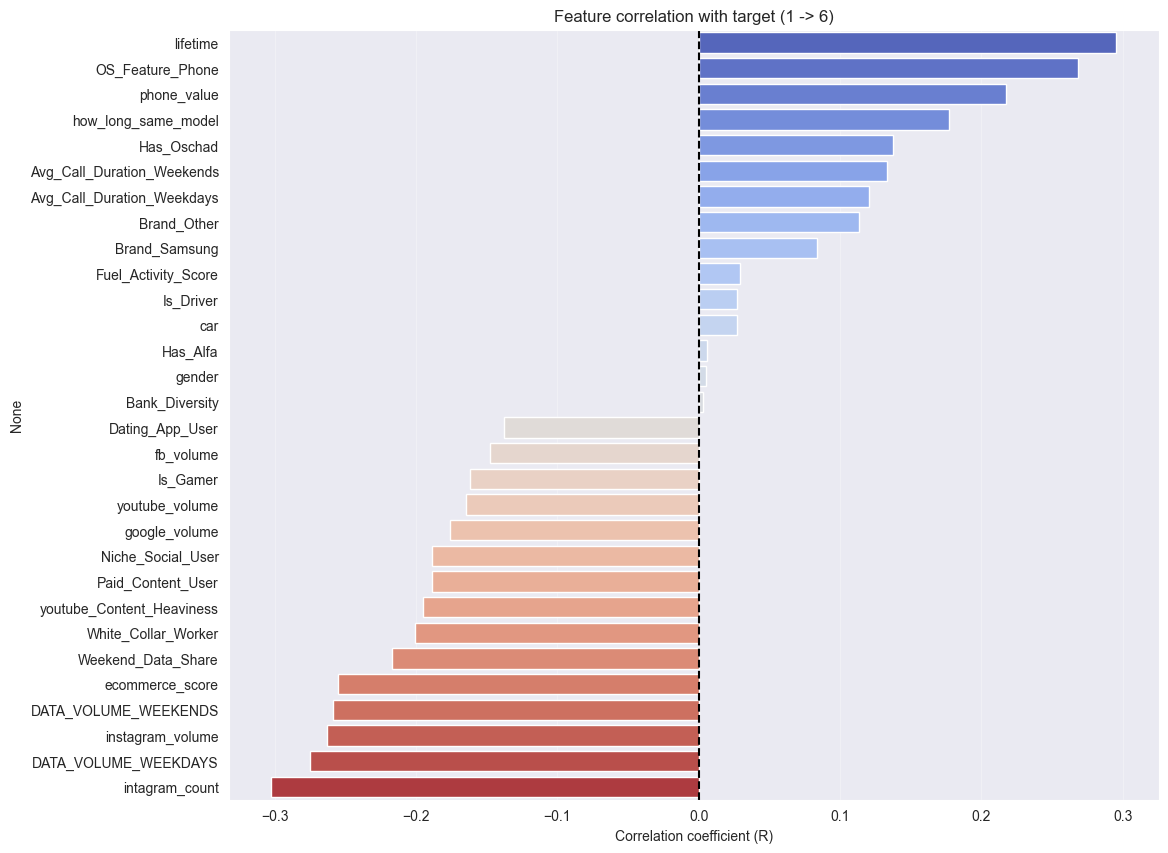

Increasing by age (Top 5):
lifetime               0.295456
OS_Feature_Phone       0.268715
phone_value            0.217787
how_long_same_model    0.177303
Has_Oschad             0.137780
Name: target, dtype: float64

Decreasing by age (Top 5):
ecommerce_score        -0.255177
DATA_VOLUME_WEEKENDS   -0.258725
instagram_volume       -0.262676
DATA_VOLUME_WEEKDAYS   -0.275108
intagram_count         -0.302794
Name: target, dtype: float64


In [82]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['number'])
corr_with_target = numeric_df.corr()['target'].sort_values(ascending=False)

corr_with_target = corr_with_target.drop('target', errors='ignore')

plt.figure(figsize=(12, 10))

top_corrs = pd.concat([corr_with_target.head(15), corr_with_target.tail(15)])

sns.barplot(x=top_corrs.values, y=top_corrs.index, palette='coolwarm', hue = top_corrs.index, legend = False)
plt.title('Feature correlation with target (1 -> 6)')
plt.xlabel('Correlation coefficient (R)')
plt.axvline(x=0, color='black', linestyle='--')
plt.grid(axis='x', alpha=0.3)
plt.show()

print("Increasing by age (Top 5):")
print(corr_with_target.head(5))
print("\nDecreasing by age (Top 5):")
print(corr_with_target.tail(5))

### Портрет поколінь (Heatmap)
Візуалізуємо середні значення ключових метрик для кожної вікової групи. Це дозволяє побачити **нелінійні залежності**:
* **Пік платоспроможності (`Affluence_Index`):** Максимальний у групах 3 та 4 (36-55 років). Це "золотий" сегмент для бізнесу.
* **Цифровий розрив:** `Digital_Introvert_Score` (Інтернет/Дзвінки) високий у груп 1-3 і різко падає у груп 5-6.
* **Технології:** Частка iOS максимальна у молоді, а Viber - у дорослих.

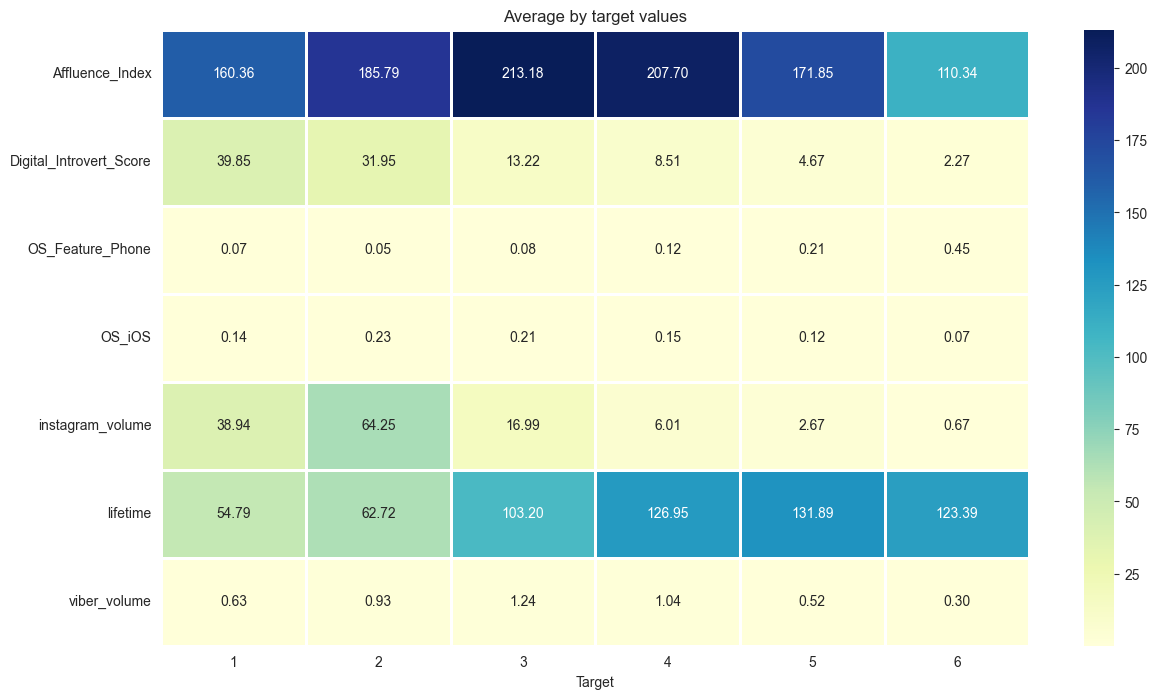

In [83]:
features_to_analyze = [
    'Tech_Conservatism',
    'Affluence_Index',
    'Digital_Introvert_Score',
    'instagram_volume',
    'viber_volume',
    'lifetime',
    'OS_Feature_Phone',
    'OS_iOS'
]

available_features = [f for f in features_to_analyze if f in df.columns]

pivot_6 = df.pivot_table(index='target', values=available_features, aggfunc='mean')

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_6.T, annot=True, fmt='.2f', cmap='YlGnBu', linewidths=1)
plt.title('Average by target values')
plt.xlabel('Target')
plt.show()

### Технологічні звички: ОС та Цифровий профіль
Аналізуємо пристрої та стиль спілкування.
1. **`Tech_Refresh_Rate` (Лівий графік):** Відношення віку телефону до стажу в мережі.
   * **Парадокс Молоді (Група 1):** Медіана найвища саме тут. Оскільки у студентів короткий стаж (`lifetime`), їхній поточний телефон займає значну частину їхньої історії.
   * **Стабільність Дорослих (3-6):** Показник нижчий, бо їхній стаж (10+ років) значно перевищує вік будь-якого телефону.
2. **`Digital_Introvert` (Правий графік):**
   * **Ідеальна градація:** Логарифмічна шкала показує, що молодь (1-2) генерує в **10-100 разів** більше інтернет-трафіку на один дзвінок, ніж пенсіонери (6), які використовують телефон майже виключно для голосу.
3. **Розподіл ОС (Нижній графік):**
   * **Група 6 (Seniors):** Найсильніший інсайт. Майже **50%** користувачів мають **Feature Phone** (кнопочні телефони).
   * **Група 2 (Young Adults):** Найвища частка **iOS** - ознака платоспроможності.

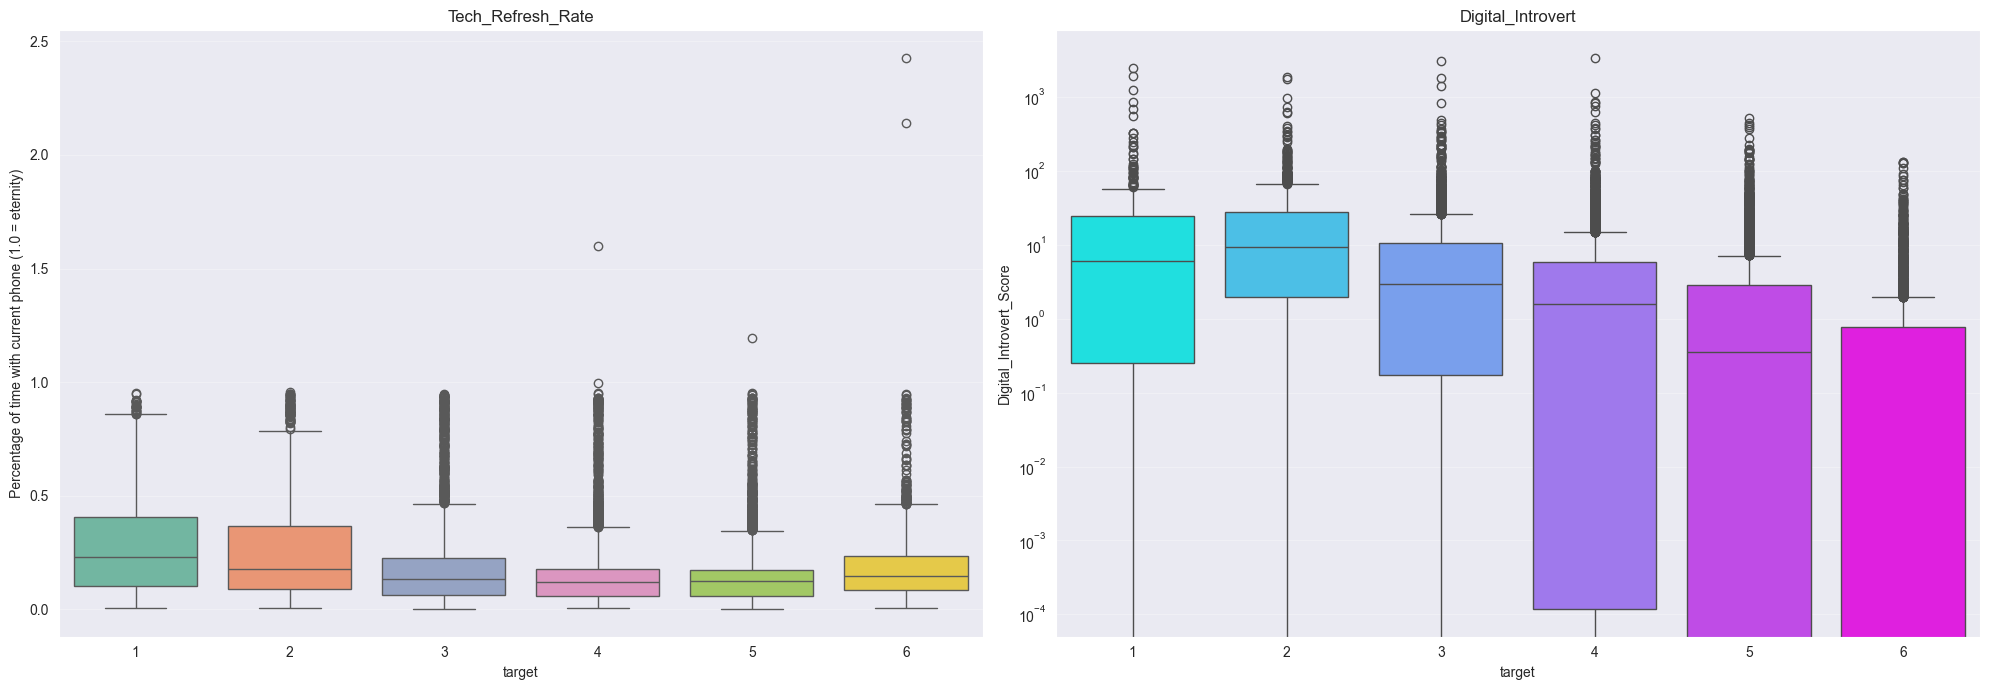

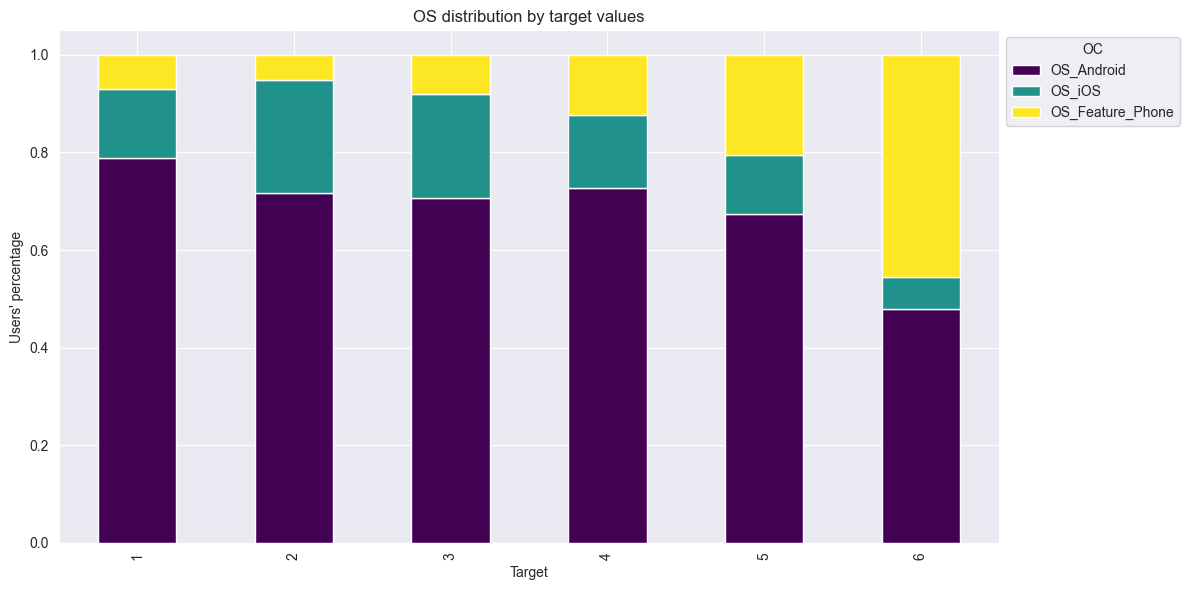

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# 1. Tech Refresh Rate
sns.boxplot(x='target', y='Tech_Refresh_Rate', hue='target', legend=False, data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Tech_Refresh_Rate')
axes[0].set_ylabel('Percentage of time with current phone (1.0 = eternity)')
axes[0].grid(axis='y', alpha=0.3)

# 2. Digital Introvert
sns.boxplot(x='target', y='Digital_Introvert_Score', hue='target', legend=False, data=df, palette='cool', ax=axes[1])
axes[1].set_title('Digital_Introvert')
axes[1].set_yscale('log')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# --- OS distribution ---
os_cols = ['OS_Android', 'OS_iOS', 'OS_Feature_Phone']
if all(col in df.columns for col in os_cols):
    os_data = df.groupby('target')[os_cols].mean()

    os_data.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
    plt.title('OS distribution by target values')
    plt.ylabel('Users\' percentage')
    plt.xlabel('Target')
    plt.legend(title='ОС', bbox_to_anchor=(1.0, 1))
    plt.tight_layout()
    plt.show()

### Маятникова міграція
Перевіряємо гіпотезу про те, що працююче населення (Adults) більше пересувається містом.
* **`Commute_Distance_KM`:** У груп 3 та 4 медіанна відстань до роботи становить 20-24 км (живуть у спальних районах, працюють у центрі).
* **Частка "Домосідів":** У студентів (гуртожитки поруч з ВНЗ) та пенсіонерів відстань до "роботи" часто дорівнює нулю або мінімальна. Це дозволяє чітко відокремити працюючий сегмент.

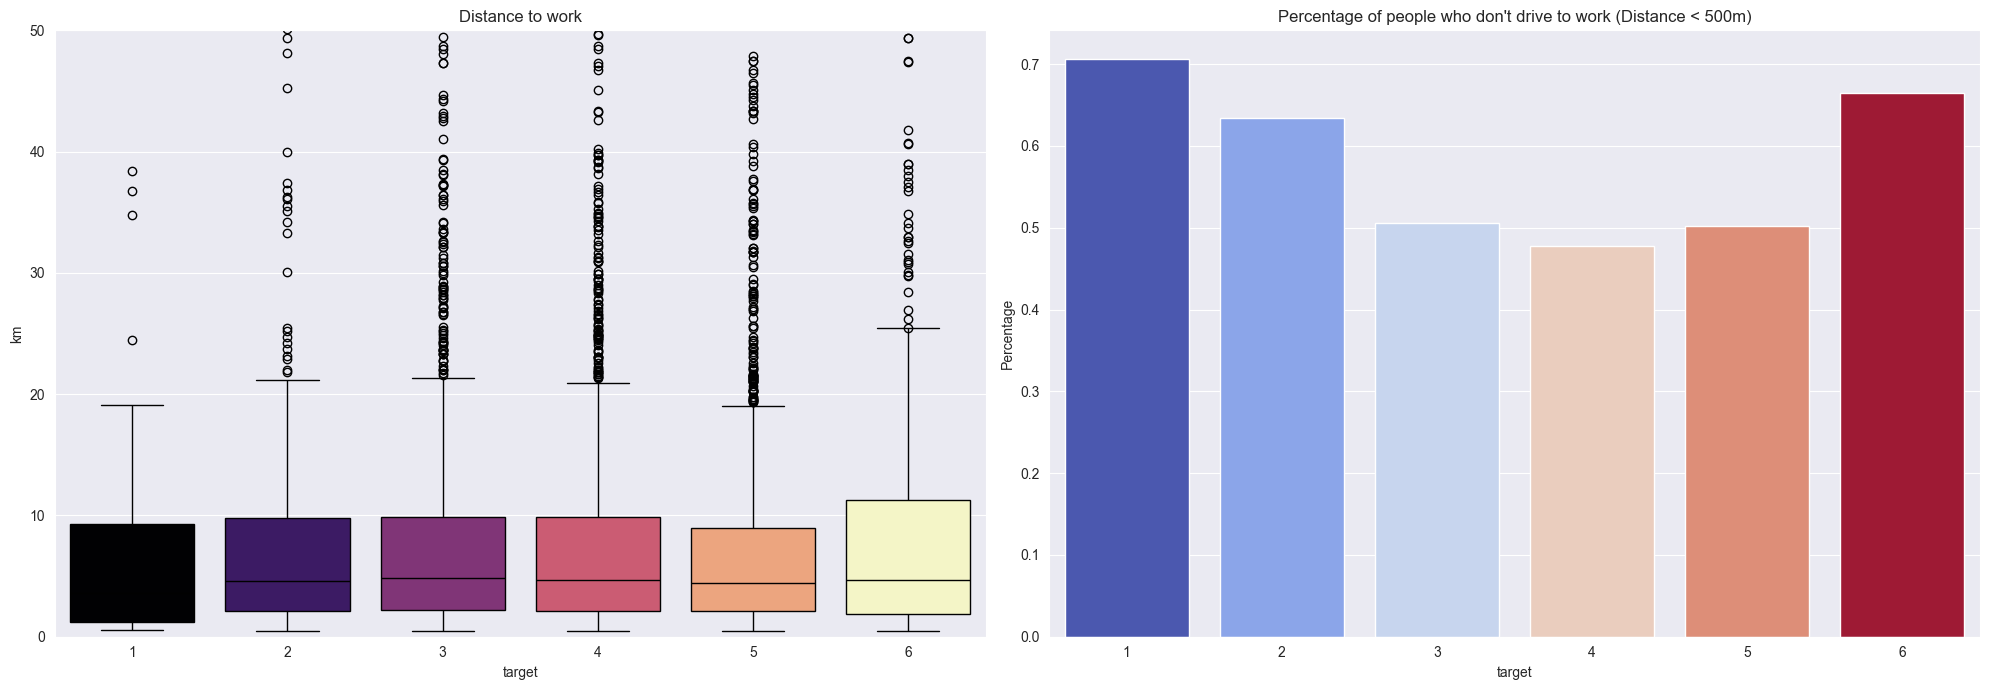

Average distance to work by target values (km):
target
1     6.278665
2     8.934152
3    24.156381
4    20.384614
5    12.455918
6    13.000160
Name: Commute_Distance_KM, dtype: float64


In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

commuters = df[df['Commute_Distance_KM'] > 0.5]

sns.boxplot(x='target', y='Commute_Distance_KM', hue = 'target', data=commuters, palette='magma', ax=axes[0], legend = False)
axes[0].set_title('Distance to work')
axes[0].set_ylabel('km')
axes[0].set_ylim(0, 50)

df['Is_Home_Worker'] = (df['Commute_Distance_KM'] < 0.5).astype(int)
home_share = df.groupby('target')['Is_Home_Worker'].mean()

sns.barplot(x=home_share.index, y=home_share.values, hue = home_share.index, palette='coolwarm', ax=axes[1], legend = False)
axes[1].set_title('Percentage of people who don\'t drive to work (Distance < 500m)')
axes[1].set_ylabel('Percentage')

plt.tight_layout()
plt.show()

print("Average distance to work by target values (km):")
print(df.groupby('target')['Commute_Distance_KM'].mean())

### Урбанізація та Щільність населення
Аналізуємо, чи впливає тип населеного пункту на вік абонента.
* **Результат:** Розподіл мешканців великих міст (`Is_Big_City`) майже рівномірний по всіх вікових групах. Це означає, що сам факт проживання в Києві чи Одесі не є сильним предиктором віку.
* **`Raion_Density`:** Також не показує суттєвої різниці, що свідчить про змішану демографію в різних районах міст.

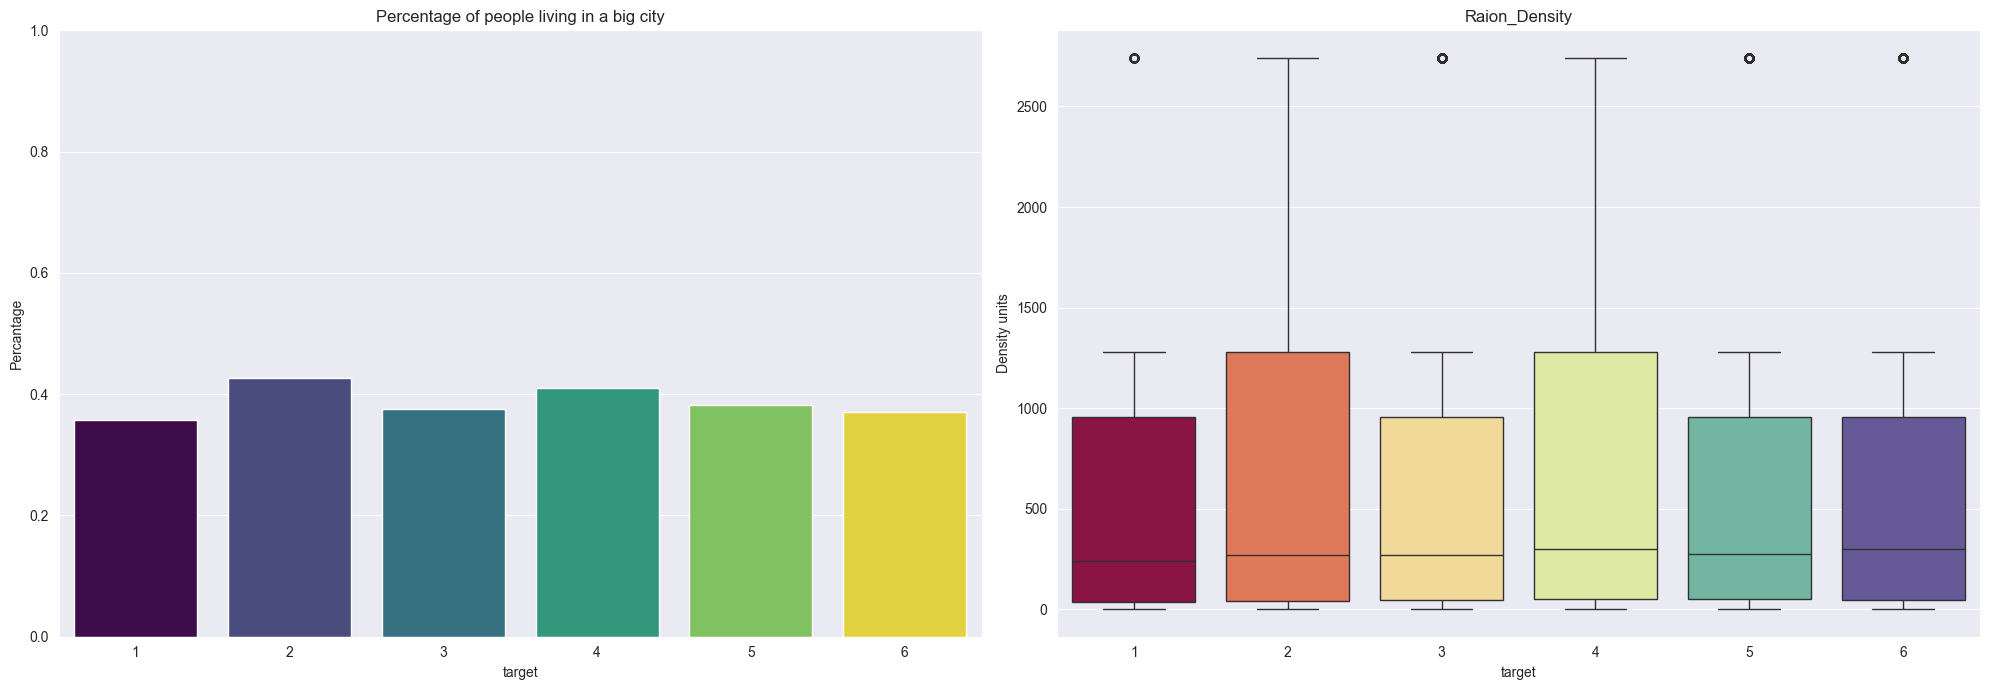

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

big_city_share = df.groupby('target')['Is_Big_City'].mean()
sns.barplot(x=big_city_share.index, y=big_city_share.values, hue = big_city_share.index, palette='viridis', ax=axes[0], legend = False)
axes[0].set_title('Percentage of people living in a big city')
axes[0].set_ylabel('Percantage')
axes[0].set_ylim(0, 1)

sns.boxplot(x='target', y='Raion_Density', hue = 'target', data=df, palette='Spectral', ax=axes[1], legend = False)
axes[1].set_title('Raion_Density')
axes[1].set_ylabel('Density units')

plt.tight_layout()
plt.show()

### Мобільний профіль: Авто vs Таксі
Аналізуємо транспортні звички:
1. **Таксі (`Taxi_User`):** Пік популярності у групи 2 (Young Adults/Students). У них вже є гроші, але ще немає власного авто (або бажання водити).
2. **Власне авто (`Is_Driver`, `car`):** Максимальна концентрація у груп 3, 4 та 5 (сімейні люди, які їздять на роботу/закупки).
3. **Роумінг (`ROUM`):** Активність різко падає в групі 6 (пенсіонери рідше подорожують).

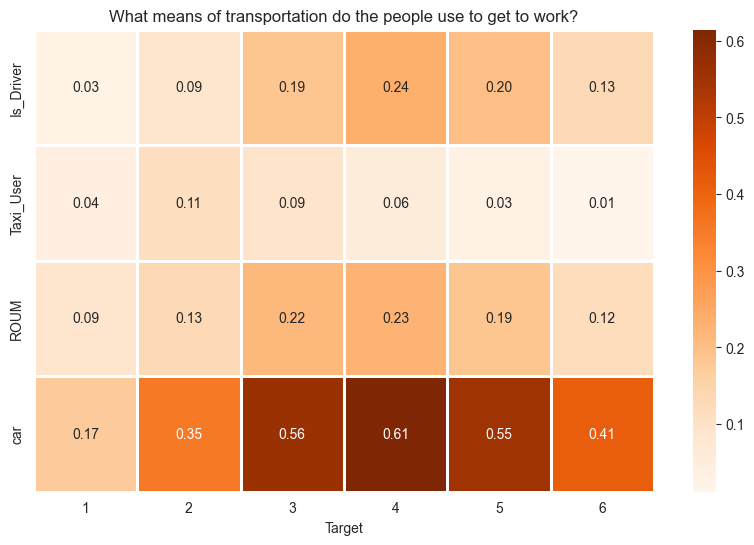

In [87]:
mobility_features = ['Is_Driver', 'Taxi_User', 'ROUM', 'car']
mobility_data = df.groupby('target')[mobility_features].mean()

plt.figure(figsize=(10, 6))
sns.heatmap(mobility_data.T, annot=True, fmt='.2f', cmap='Oranges', linewidths=1)
plt.title('What means of transportation do the people use to get to work?')
plt.xlabel('Target')
plt.show()

### Фінансовий профіль: Гроші та Статус
1. **`Affluence_Index`:** Комбінований показник багатства (ARPU * Клас телефону). Чітко виділяє "горб" у середньому віці (35-55 років) - це найбільш платоспроможна аудиторія.
2. **Категорія телефону:** З віком люди переходять від флагманів (1) до бюджетних моделей (4).
3. **ARPU:** Пенсіонери (група 6) мають найнижчий середній чек, в той час як Adults (3-4) приносять найбільше доходу компанії.

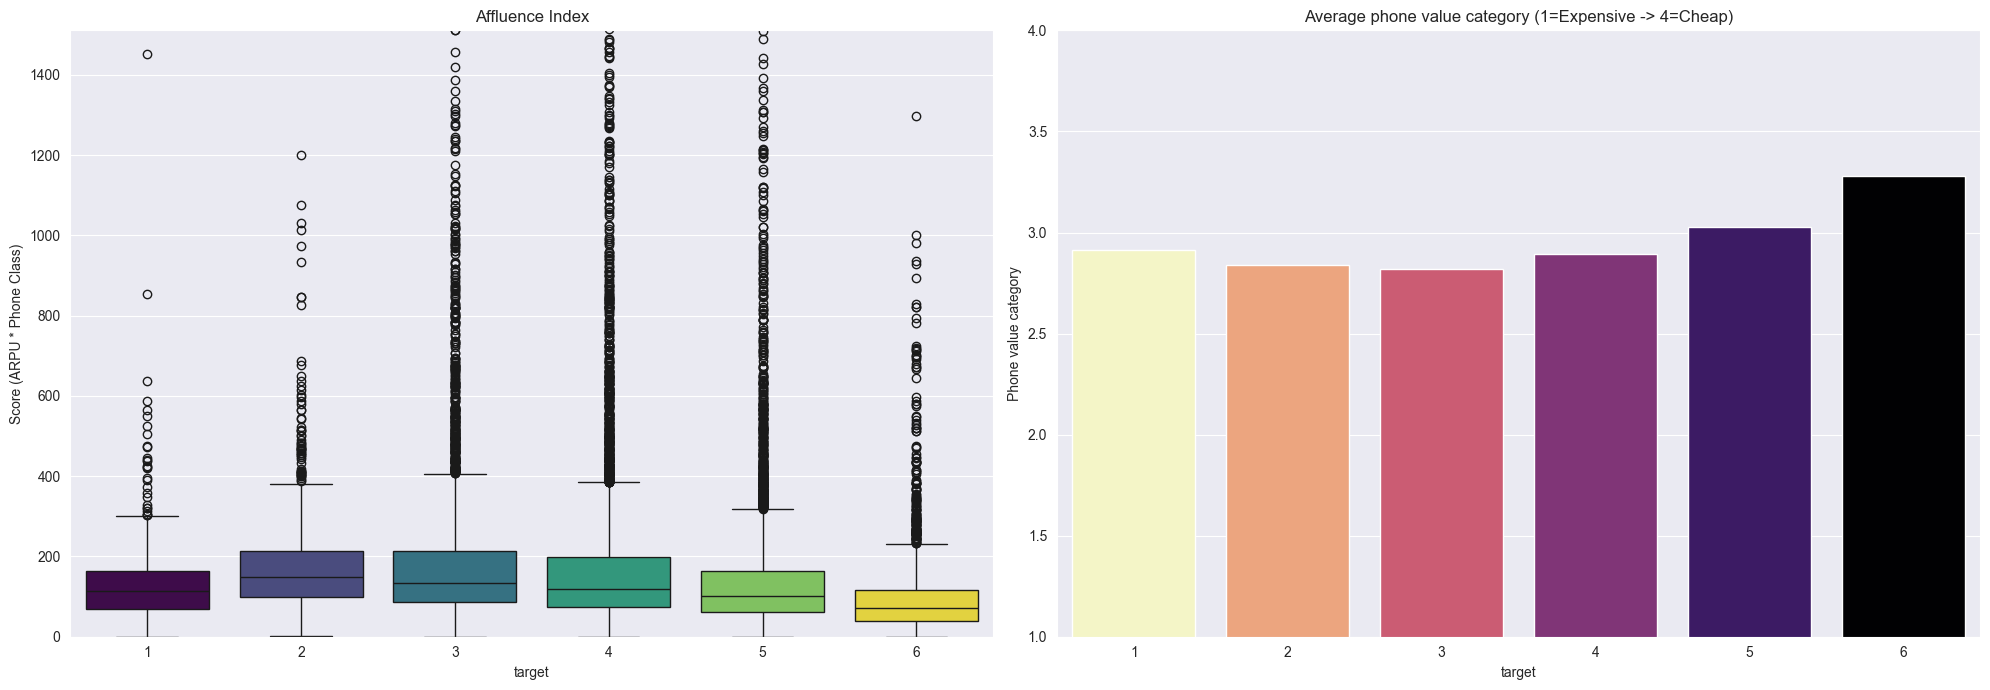

ARPU by target values:
target
1    69.800089
2    81.053104
3    87.675452
4    87.959355
5    77.939368
6    58.684753
Name: AVG_ARPU, dtype: float64


In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

sns.boxplot(x='target', y='Affluence_Index', hue = 'target', data=df, palette='viridis', ax=axes[0], legend = False)
axes[0].set_title('Affluence Index')
axes[0].set_ylabel('Score (ARPU * Phone Class)')
axes[0].set_ylim(0, df['Affluence_Index'].quantile(0.99))

phone_val_mean = df.groupby('target')['phone_value'].mean()
sns.barplot(x=phone_val_mean.index, y=phone_val_mean.values, hue = phone_val_mean.index, palette='magma_r', ax=axes[1], legend = False)
axes[1].set_title('Average phone value category (1=Expensive -> 4=Cheap)')
axes[1].set_ylabel('Phone value category')
axes[1].set_ylim(1, 4)

plt.tight_layout()
plt.show()

print("ARPU by target values:")
print(df.groupby('target')['AVG_ARPU'].mean())

### Банківський ландшафт: "Ефект Ощадбанку"
Аналіз банківських СМС дає нам такi результати:
* **`Has_Oschad`:** Частка клієнтів Ощадбанку зростає з 3% у молоді до 31% у пенсіонерів. Це надзвичайно сильний маркер віку.
* **`Has_Privat`:** Є у всіх, тому слабко розрізняє групи.
* **`Bank_Diversity`:** Молодь та дорослі частіше користуються кількома банками одночасно, пенсіонери - зазвичай одним.

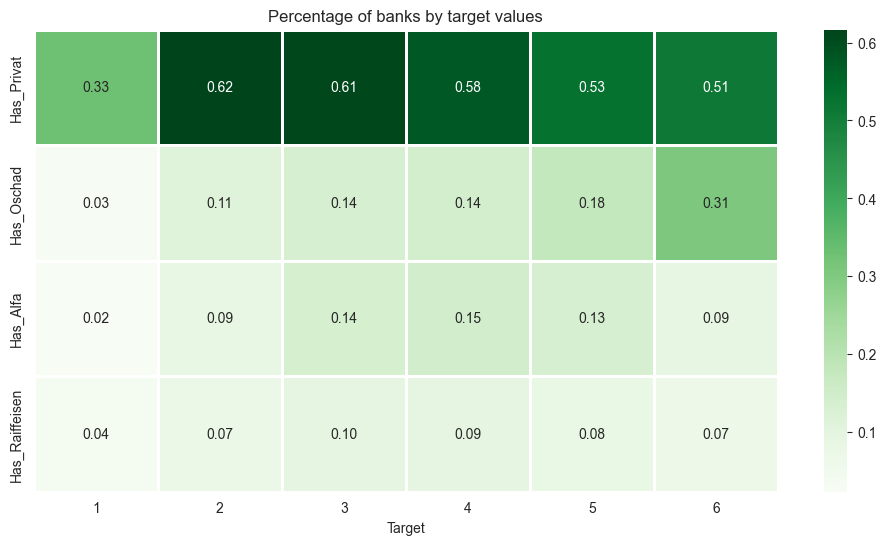

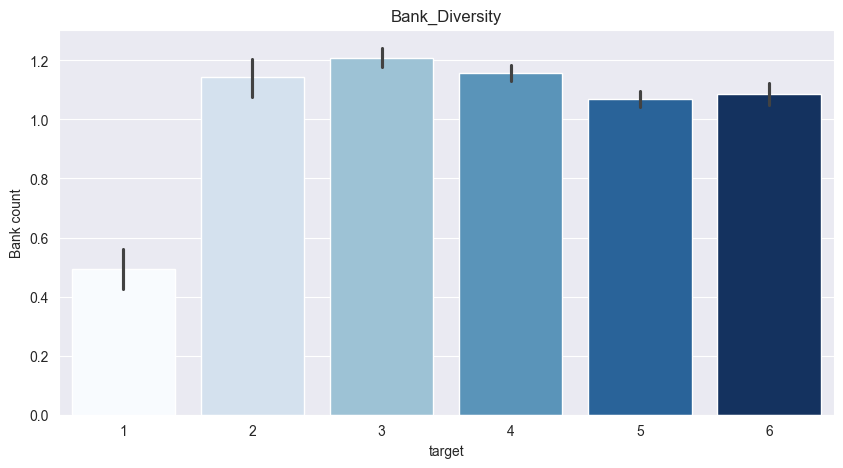

In [89]:
bank_cols = ['Has_Privat', 'Has_Oschad', 'Has_Alfa', 'Has_Raiffeisen']

bank_share = df.groupby('target')[bank_cols].mean()

plt.figure(figsize=(12, 6))
sns.heatmap(bank_share.T, annot=True, fmt='.2f', cmap='Greens', linewidths=1)
plt.title('Percentage of banks by target values')
plt.xlabel('Target')
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(x='target', y='Bank_Diversity', hue = 'target', data=df, palette='Blues', legend = False)
plt.title('Bank_Diversity')
plt.ylabel('Bank count')
plt.show()

### Цифрова комерція та Платний контент
* **`Ecommerce_Score`:** Схильність до онлайн-покупок максимальна у групи 2 (Young Adults), які активно купують товари в мережі. У пенсіонерів цей показник мінімальний.
* **`Paid_Content_User`:** Підписки, ігри та музика - це територія молоді (групи 1-2). З віком інтерес до платного цифрового контенту згасає.

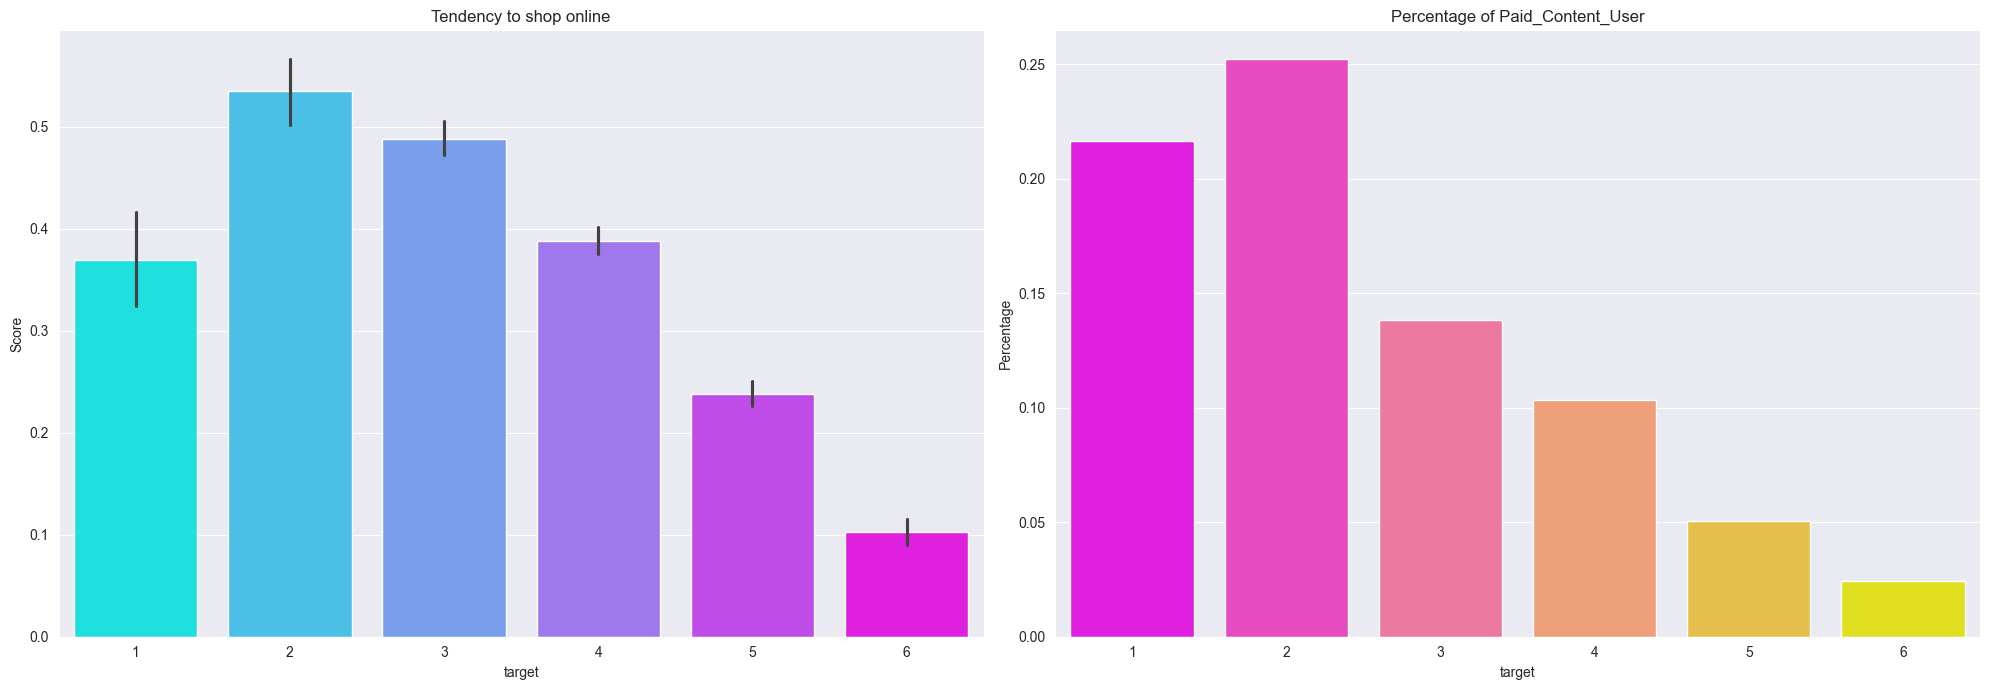

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

sns.barplot(x='target', y='ecommerce_score', hue = 'target', data=df, palette='cool', ax=axes[0], legend = False)
axes[0].set_title('Ecommerce Score')
axes[0].set_title('Tendency to shop online')
axes[0].set_ylabel('Score')

paid_content_share = df.groupby('target')['Paid_Content_User'].mean()
sns.barplot(x=paid_content_share.index, y=paid_content_share.values, hue = paid_content_share.index, palette='spring', ax=axes[1], legend = False)
axes[1].set_title('Percentage of Paid_Content_User')
axes[1].set_ylabel('Percentage')

plt.tight_layout()
plt.show()